In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

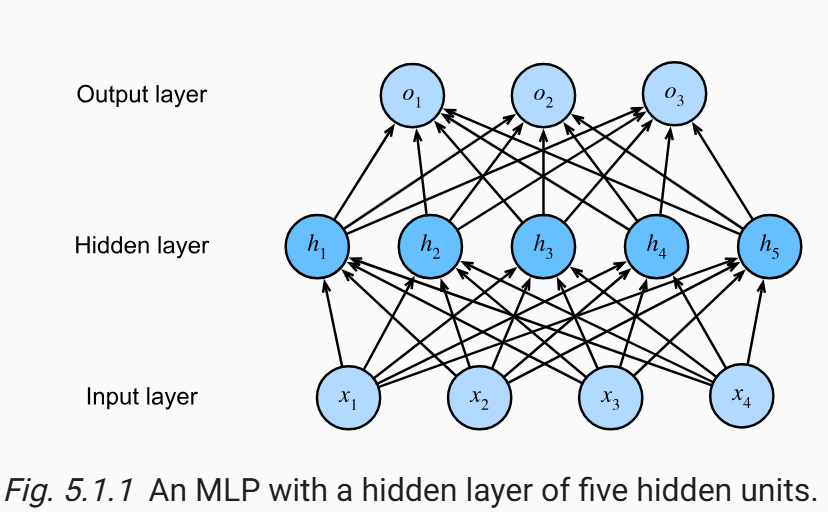

For the above MLP - One Input Layer, One Hidden Layer and One Output Layer
1. Input Layer - X - Dimension n x d (n = number of examples / mini-batch size, d - dimension of input)
2. Hidden Layer - Weights W1 = d x h (h = number of hidden units), b1 = 1 x h - dimension of bias)
3. Hidden layer output - H = n x h - The hidden layer transforms the d dimensional input intp a h dimensional space
4. Output layer - W2 = h x q (q = number of units in output layer), b2 = 1 x q - dimension of bias)
5. Output layer output - O = n x q

H = g(XW1 + b1) - where g is a non-linear activation function. This non-linearity is required because without it stacking linear layers on top of each other results into a linear layer
O = Hw2 + b2

Activation Function g adds non-linearity to the network and result in its expressiveness. Below we look at the most commonly used activation functions

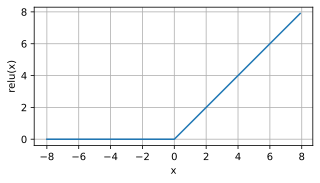

In [ ]:
#RELU - max(0, x) - sqashes negative values and only passes positive values through
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5,2.5))

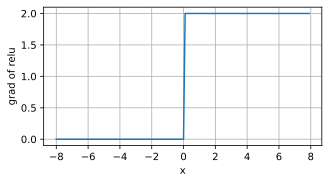

In [ ]:
#The gradient of the activation function is 1 in the positive region and 0 in negative. Thus relu either stops
#the gradient or lets the gradient through in backward propogation
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5,2.5))

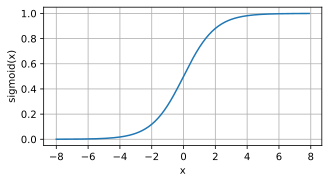

In [ ]:
#Sigmoid activation - sigmoid(x) = 1/ (1+ exp**-x). When the input x is close to 0 sigmoid is same as linear transformation
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

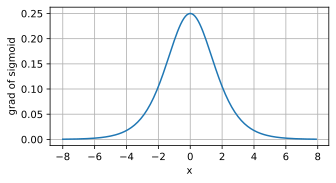

In [ ]:
#Derivative of Sigmoid is given by sigmoid(x)(1-sigmoid(x)). 
#Derivative of a sigmoid attains a max of 0.25 when input is zero and approaches 0 as x diverges for zero in both directions
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5,2.5))


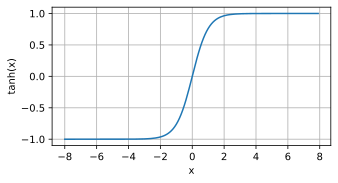

In [7]:
#Tanh activation - tanh(x) = (1 - exp**(-2x)) / (1 + exp**(-2x)). When the input x is close to 0 sigmoid is same as linear transformation.
#Unlike sigmoid tanh is symmetric around the origin
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

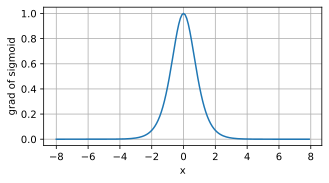

In [8]:
#Derivative of tanh is given by 1-tanh(x)**2
#Derivative of a tanh attains a max of 1 when input is zero and approaches 0 as x diverges for zero in both directions
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5,2.5))